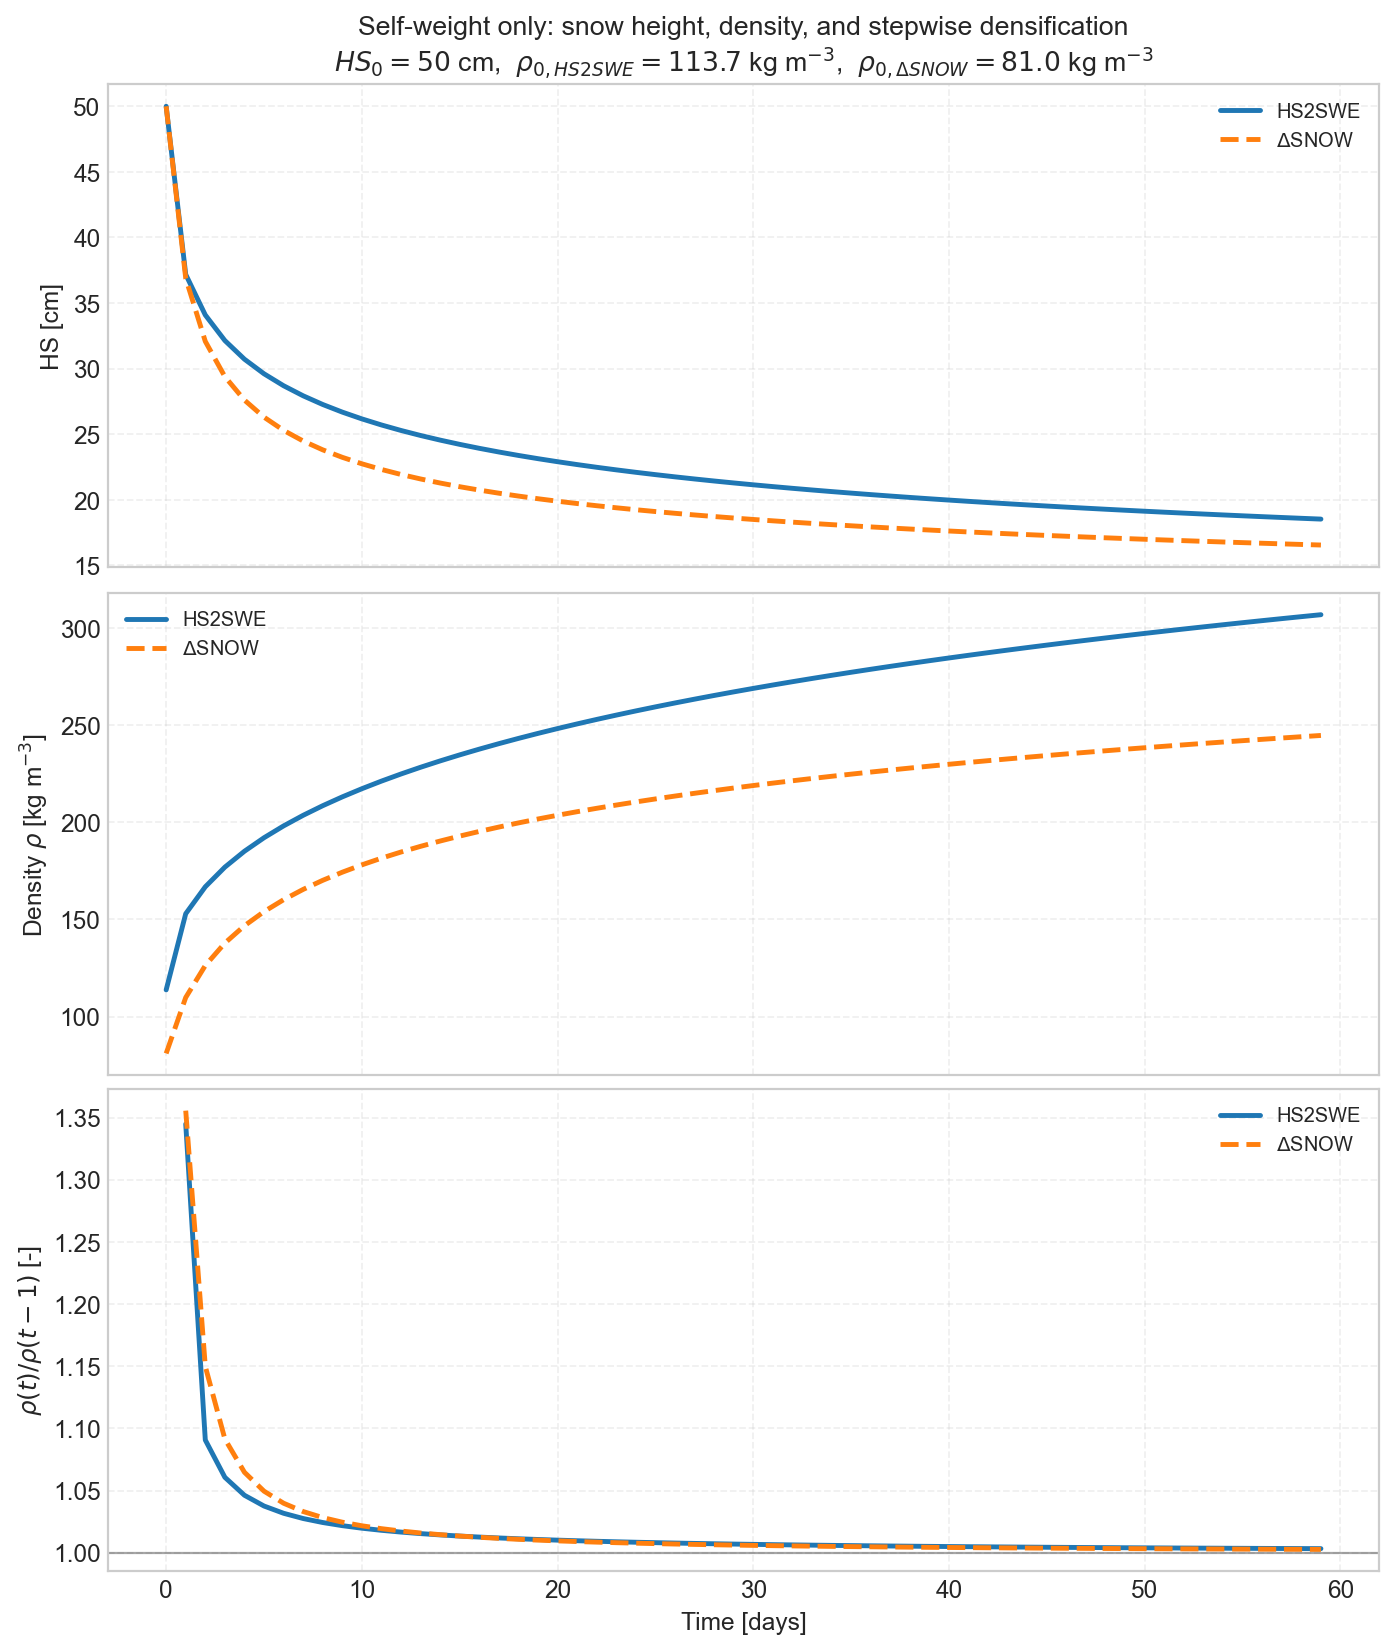

In [9]:
"""
Dry compaction module (HS2SWE vs ΔSNOW) — self-weight only, clean + working

What this script does (once, in a sensible order):
1) Defines both single-layer compaction step functions (self-weight included).
2) Runs ONE experiment (no external sigma_levels) for one initial condition.
3) Produces ONE figure with 3 panels:
   - HS(t) [cm]
   - rho(t) [kg m^-3]
   - stepwise densification factor: rho(t)/rho(t-1)

Notes
-----
- "Self-weight only" means: ovb_kg_m2 = 0.0 (no imposed load above the layer).
- Both models include self-weight via the layer SWE.
- The stepwise densification factor is computed for each model separately.
"""

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# ------------------------------------------------------------
# Globals: updated on every HS2SWE call (last step values)
# ------------------------------------------------------------
HS2SWE_TERM_OVB = np.nan        # [s^-1]
HS2SWE_TERM_METAMORPH = np.nan  # [s^-1]


# ============================================================
# HS2SWE step (single layer)
# ============================================================
def hs2swe_single_layer_step(
    hs_cm: float,
    rho: float,
    ovb_kg_m2: float = 0.0,
    SnoTemp: float = 0.0,
    dt_s: float = 86400.0,
    g: float = 9.81,
    include_self_weight: bool = True,
    rho_new: float = 113.7,
    rho_max: float = 571.6,
    visc: float = 6.051e7,
    c1: float = 2.8e-6,
    c2: float = 0.042,
    c3: float = 0.046,
    c4: float = 0.081,
    c5: float = 0.018,
):
    """
    HS2SWE: one dry-compaction step for a single homogeneous layer.

    Stress handling:
      - ovb_kg_m2 is imposed mass above the layer [kg m^-2]
      - if include_self_weight=True, stress uses (ovb_kg_m2 + SWE_layer)

    Returns:
      hs_cm_new, rho_new_val
    """
    global HS2SWE_TERM_OVB, HS2SWE_TERM_METAMORPH

    hs_cm = float(hs_cm)
    rho_safe = max(float(rho), 1e-12)

    # SWE of the layer [kg m^-2] (constant during dry compaction)
    swe = (hs_cm / 100.0) * rho_safe

    # mass driving compaction [kg m^-2]
    stress_mass = (ovb_kg_m2 + swe) if include_self_weight else ovb_kg_m2

    # mechanical compaction term [s^-1]
    term_overburden = (stress_mass * g) / (visc * np.exp(c4 * SnoTemp + c5 * rho_safe))

    # metamorphism term [s^-1]
    term_metamorph = c1 * np.exp(-c2 * SnoTemp - c3 * max(0.0, rho_safe - rho_new))

    # store globals (last call)
    HS2SWE_TERM_OVB = term_overburden
    HS2SWE_TERM_METAMORPH = term_metamorph

    # density update
    rho_new_val = rho_safe + rho_safe * dt_s * (term_overburden + term_metamorph)
    rho_new_val = min(rho_new_val, rho_max)

    # SWE conserved -> height adjusts inversely with density
    hs_cm_new = hs_cm * (rho_safe / rho_new_val)

    return hs_cm_new, rho_new_val


# ============================================================
# ΔSNOW step (single layer)
# ============================================================
def dsnow_single_layer_step(
    hs_cm: float,
    rho: float,
    ovb_kg_m2: float = 0.0,
    dt_s: float = 86400.0,
    g: float = 9.81,
    eta0_Pa_s: float = 8.5e6,
    k_m3_kg: float = 0.030,
    rho_max: float = 401.0,
):
    """
    ΔSNOW: one dry-compaction step for a single homogeneous layer.

    Bottom stress:
      b_sigma = g * (ovb_kg_m2 + SWE_layer)
    so self-weight is always included via +SWE_layer.

    Returns:
      hs_cm_new, rho_new
    """
    hs_cm = float(hs_cm)
    rho = float(rho)

    # SWE constant during dry compaction [kg m^-2]
    swe = (hs_cm / 100.0) * rho

    # height in meters
    hs_m = max(hs_cm / 100.0, 1e-12)

    # density consistent with SWE/hs
    rho_safe = swe / hs_m

    # bottom stress [Pa]
    b_sigma = g * (ovb_kg_m2 + swe)

    # effective viscosity
    eta = eta0_Pa_s * np.exp(k_m3_kg * rho_safe)

    # compaction update
    comp_factor = 1.0 + dt_s * (b_sigma / eta)
    hs_m_new = hs_m / comp_factor

    # enforce max density -> min height
    hs_m_new = max(hs_m_new, swe / rho_max)
    rho_new = swe / max(hs_m_new, 1e-12)

    return hs_m_new * 100.0, rho_new


# ============================================================
# Style
# ============================================================
def set_pub_style():
    plt.style.use("seaborn-v0_8-whitegrid")
    plt.rcParams.update({
        "figure.dpi": 160,
        "savefig.dpi": 300,
        "font.size": 11,
        "axes.titlesize": 12,
        "axes.labelsize": 11,
        "legend.fontsize": 9,
        "lines.linewidth": 2.2,
        "grid.alpha": 0.3,
        "grid.linestyle": "--",
    })


# ============================================================
# Experiment runner (self-weight only)
# ============================================================
def run_self_weight_experiment(
    hs0_cm: float,
    rho0_hs2: float,
    rho0_ds: float,
    SnoTemp: float,
    dt_s: float,
    n_days: int,
    g: float,
):
    t_days = np.arange(n_days)

    HS_hs2 = np.zeros(n_days)
    RHO_hs2 = np.zeros(n_days)
    HS_ds = np.zeros(n_days)
    RHO_ds = np.zeros(n_days)

    HS_hs2[0] = hs0_cm
    RHO_hs2[0] = rho0_hs2
    HS_ds[0] = hs0_cm
    RHO_ds[0] = rho0_ds

    # self-weight only -> ovb_kg_m2 = 0
    ovb_kg_m2 = 0.0

    for i in range(1, n_days):
        HS_hs2[i], RHO_hs2[i] = hs2swe_single_layer_step(
            HS_hs2[i - 1],
            RHO_hs2[i - 1],
            ovb_kg_m2=ovb_kg_m2,
            SnoTemp=SnoTemp,
            dt_s=dt_s,
            g=g,
            include_self_weight=True,
        )

        HS_ds[i], RHO_ds[i] = dsnow_single_layer_step(
            HS_ds[i - 1],
            RHO_ds[i - 1],
            ovb_kg_m2=ovb_kg_m2,
            dt_s=dt_s,
            g=g,
        )

    SWE_hs2 = (HS_hs2 / 100.0) * RHO_hs2
    SWE_ds = (HS_ds / 100.0) * RHO_ds

    return {
        "t_days": t_days,
        "HS_hs2": HS_hs2,
        "RHO_hs2": RHO_hs2,
        "SWE_hs2": SWE_hs2,
        "HS_ds": HS_ds,
        "RHO_ds": RHO_ds,
        "SWE_ds": SWE_ds,
        "rho0_hs2": rho0_hs2,
        "rho0_ds": rho0_ds,
        "hs0_cm": hs0_cm,
    }


# ============================================================
# Plot: HS, rho, densification factor rho(t)/rho(t-1)
# ============================================================
def plot_hs_rho_densification(sim, outfile="self_weight_hs_rho_densification.png"):
    t = sim["t_days"]
    HS_hs2 = sim["HS_hs2"]
    HS_ds = sim["HS_ds"]
    RHO_hs2 = sim["RHO_hs2"]
    RHO_ds = sim["RHO_ds"]

    # Stepwise densification factor
    F_hs = np.full_like(RHO_hs2, np.nan, dtype=float)
    F_ds = np.full_like(RHO_ds, np.nan, dtype=float)
    F_hs[1:] = RHO_hs2[1:] / RHO_hs2[:-1]
    F_ds[1:] = RHO_ds[1:] / RHO_ds[:-1]

    fig, axes = plt.subplots(3, 1, figsize=(8.6, 10.2), sharex=True, constrained_layout=True)

    # (1) HS
    axes[0].plot(t, HS_hs2, ls="-",  label="HS2SWE")
    axes[0].plot(t, HS_ds,  ls="--", label=r"$\Delta$SNOW")
    axes[0].set_ylabel("HS [cm]")
    axes[0].set_title(
        "Self-weight only: snow height, density, and stepwise densification\n"
        rf"$HS_0={sim['hs0_cm']:.0f}$ cm,  "
        rf"$\rho_{{0,HS2SWE}}={sim['rho0_hs2']:.1f}$ kg m$^{{-3}}$,  "
        rf"$\rho_{{0,\Delta SNOW}}={sim['rho0_ds']:.1f}$ kg m$^{{-3}}$"
    )
    axes[0].legend(loc="best")

    # (2) rho
    axes[1].plot(t, RHO_hs2, ls="-",  label="HS2SWE")
    axes[1].plot(t, RHO_ds,  ls="--", label=r"$\Delta$SNOW")
    axes[1].set_ylabel(r"Density $\rho$ [kg m$^{-3}$]")
    axes[1].legend(loc="best")

    # (3) densification factor
    axes[2].plot(t, F_hs, ls="-",  label="HS2SWE")
    axes[2].plot(t, F_ds, ls="--", label=r"$\Delta$SNOW")
    axes[2].axhline(1.0, color="black", lw=1.0, alpha=0.35)
    axes[2].set_ylabel(r"$\rho(t)/\rho(t-1)$ [-]")
    axes[2].set_xlabel("Time [days]")
    axes[2].legend(loc="best")

    plt.savefig(outfile, bbox_inches="tight")
    plt.show()


# ============================================================
# MAIN
# ============================================================
def main():
    set_pub_style()

    # --- user-controlled experiment settings ---
    DT_S = 86400.0
    N_DAYS = 60
    G = 9.81
    SNOTEMP = 0.0
    HS0_CM = 50.0

    # Calibrated / chosen initial densities (edit here)
    RHO0_HS2 = 113.7  # e.g. HS2SWE fresh-snow reference
    RHO0_DS = 81.0    # e.g. ΔSNOW fresh-snow reference

    sim = run_self_weight_experiment(
        hs0_cm=HS0_CM,
        rho0_hs2=RHO0_HS2,
        rho0_ds=RHO0_DS,
        SnoTemp=SNOTEMP,
        dt_s=DT_S,
        n_days=N_DAYS,
        g=G,
    )

    plot_hs_rho_densification(sim)


if __name__ == "__main__":
    main()